In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/Fake news detection /fake_news_dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake
...,...,...,...,...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,2024-12-04,BBC,Gary Miles,Entertainment,fake
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,2024-05-26,Daily News,Maria Mcbride,Entertainment,real
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,2023-04-17,BBC,Kristen Franklin,Entertainment,real
19998,School wide itself item.,term point general common training watch respo...,2024-06-30,Reuters,David Wise,Health,fake


In [ ]:
df.isna().sum()

,0
title,0
text,0
date,0
source,1000
author,1000
category,0
label,0


In [ ]:
df['source'] = df['source'].fillna('Others')

In [ ]:
df['author'] = df['author'].fillna('Unknown')

In [ ]:
df.isna().sum()

,0
title,0
text,0
date,0
source,0
author,0
category,0
label,0


## `EDA`

In [ ]:
import matplotlib.pyplot as plt

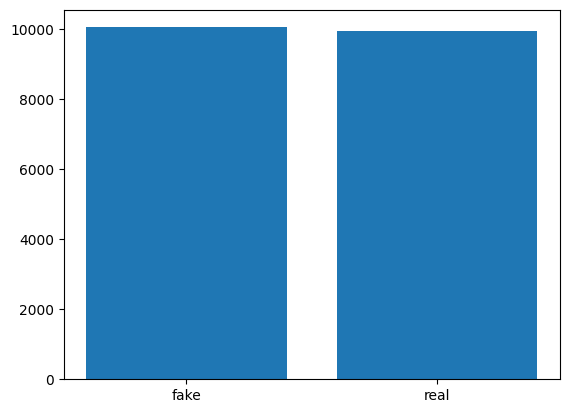

In [ ]:
labelcounts = df['label'].value_counts()
label = labelcounts.index
values = labelcounts.values
plt.bar(label,values)
plt.show()

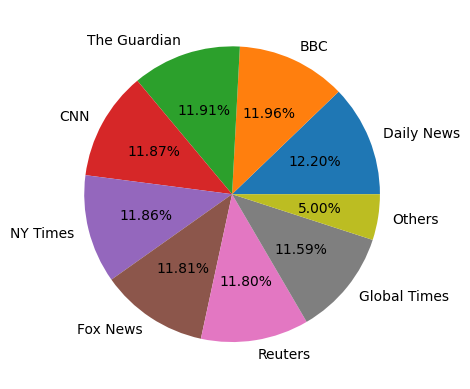

In [ ]:
labelcounts = df['source'].value_counts()
label = labelcounts.index
values = labelcounts.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

In [ ]:
df['author'].nunique()

17052

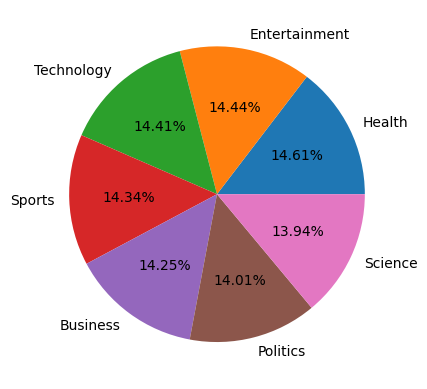

In [ ]:
labelcounts = df['category'].value_counts()
label = labelcounts.index
values = labelcounts.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

In [ ]:
temp = df.groupby('source')['author'].count()

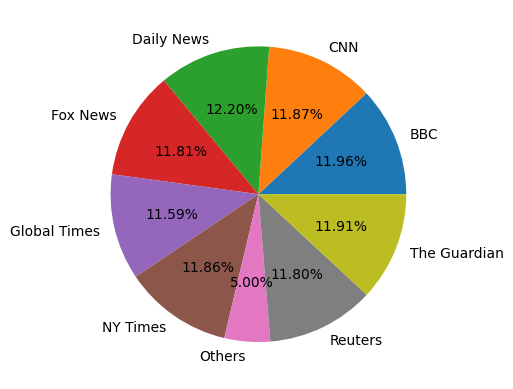

In [ ]:
label = temp.index
values = temp.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

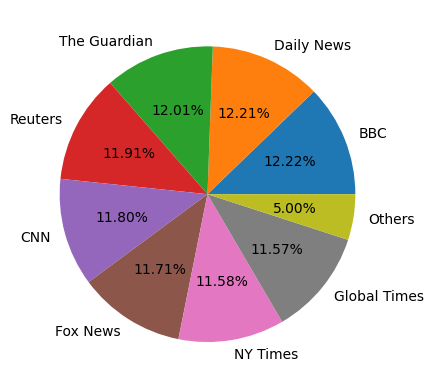

In [ ]:
temp = df[df['label']=='real']
indices = temp['source'].value_counts()
label = indices.index
values = indices.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

## `Text Preprocessing`

In [ ]:
df['Processed_data'] = df['title'] + " " + df['text']

In [ ]:
df

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,Foreign Democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,To offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,Himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,You unit its should. phone which item yard Rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,Billion believe employee summer how. wonder my...
...,...,...,...,...,...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,2024-12-04,BBC,Gary Miles,Entertainment,fake,House party born. hit and television I change ...
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,2024-05-26,Daily News,Maria Mcbride,Entertainment,real,Though nation people maybe price box. fear mos...
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,2023-04-17,BBC,Kristen Franklin,Entertainment,real,Yet exist with experience unit. activity loss ...
19998,School wide itself item.,term point general common training watch respo...,2024-06-30,Reuters,David Wise,Health,fake,School wide itself item. term point general co...


In [ ]:
#For removing any special characters
import re
#For removing stopwords
import nltk
nltk.download('stopwords',quiet = True)
#Stemming the text
from nltk.stem import PorterStemmer
#Importing NumPy
import numpy as np
# Ignore warnings
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [ ]:
df['Processed_data'] = df['Processed_data'].str.lower()
df.head()

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,to offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,you unit its should. phone which item yard rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer how. wonder my...


In [ ]:
#Removing any kind of special characters that might be present in out text by defining a function
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

df['Processed_data'] = df['Processed_data'].apply(remove_special_chars)

df.head()

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final more tax development bo...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,to offer down resource great point probably gu...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,himself church myself carry them identify forw...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,you unit its should phone which item yard repu...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer how wonder mys...


In [ ]:
#Removing stopwords from the text

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Processed_data'] = df['Processed_data'].apply(remove_stopwords)
df.head()

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final tax development store a...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,offer resource great point probably guess west...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,church carry identify forward present success ...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,unit phone item yard republican safe police id...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer wonder fact di...


In [ ]:
# Stemming the data
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
def stem_words(text):
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return " ".join(words)

df['Processed_data'] = df['Processed_data'].apply(stem_words)
display(df.head())

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final tax develop store agree...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,offer resourc great point probabl guess wester...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,church carri identifi forward present success ...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,unit phone item yard republican safe polic ide...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believ employe summer wonder fact diff...


In [ ]:
!pip install gensim

In [ ]:
import gensim

In [ ]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [ ]:
import nltk
nltk.download('punkt',quiet=True)
nltk.download('punkt_tab',quiet=True)
news = []
for doc in df['Processed_data']:
  raw_sent = sent_tokenize(doc)
  for sent in raw_sent:
    news.append(simple_preprocess(sent))

In [ ]:
len(news)

20000

In [ ]:
model = gensim.models.Word2Vec(
    window=10,
    min_count=2
)

In [ ]:
model.build_vocab(news)

In [ ]:
model.train(news,total_examples=model.corpus_count,epochs=model.epochs)

(22872475, 22886590)

In [ ]:
len(model.wv.index_to_key)

839

In [ ]:
def document_vector(doc):
  doc = [word for word in doc.split() if word in model.wv.index_to_key]
  return np.mean(model.wv[doc],axis=0)

In [ ]:
document_vector(df['Processed_data'].values[0])

array([ 7.13189889e-04,  1.11688524e-01,  2.91095190e-02,  1.07693542e-02,
        4.75303158e-02, -7.91748911e-02, -3.02345492e-02,  1.41548902e-01,
       -2.19328925e-02,  4.74032052e-02, -9.37209502e-02, -8.52846280e-02,
        1.61728598e-02,  7.05450475e-02, -1.06116701e-02,  8.83014593e-03,
        3.72816585e-02, -6.62983060e-02,  1.86379161e-02, -1.39255911e-01,
        6.35535121e-02, -1.99192483e-02,  3.18871066e-02, -5.35977893e-02,
       -8.10185596e-02, -1.78226884e-02, -7.60949925e-02, -1.55780464e-02,
        3.53864580e-02, -3.17542627e-02,  1.88313112e-01,  1.04673132e-01,
       -2.97387838e-02,  2.86939871e-02, -6.93385527e-02,  1.08360499e-01,
        6.60485166e-05, -1.35879219e-01, -1.01466008e-01, -1.62019894e-01,
        2.25958675e-02, -4.98882215e-03, -8.22571665e-03, -2.35691052e-02,
       -5.47284968e-02, -6.00221083e-02, -3.46414149e-02,  1.98305640e-02,
        7.02448413e-02,  6.99690580e-02,  4.32952866e-02, -8.81955624e-02,
       -1.15373835e-01,  

In [ ]:
from tqdm import tqdm

In [ ]:
x = []
for doc in tqdm(df['Processed_data'].values):
  x.append(document_vector(doc))

100%|██████████| 20000/20000 [00:36<00:00, 541.36it/s]


In [ ]:
x = np.array(x)

In [ ]:
x.shape

(20000, 100)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

In [ ]:
y

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
accuracy_score(y_test,y_pred)

0.49075

In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train,y_train)
y_pred = svm.predict(x_test)
accuracy_score(y_test,y_pred)

0.49875

In [ ]:
import xgboost as xgb
xgb = xgb.XGBClassifier()
xgb.fit(x_train,y_train)
y_pred = xgb.predict(x_test)
accuracy_score(y_test,y_pred)

0.5

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
accuracy_score(y_test,y_pred)

0.49475

In [ ]:
import joblib
joblib.dump(rf,'model.pkl')

['model.pkl']

In [ ]:
model.save('word2vec.model')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(df['Processed_data'], y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.501
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      2029
           1       0.49      0.49      0.49      1971

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000

